<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/06_pytorch_transfer_learning_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06. PyTorch Transfer Learning Exercises

Welcome to the 06. PyTorch Transfer Learning exercise template notebook.

There are several questions in this notebook and it's your goal to answer them by writing Python and PyTorch code.

> **Note:** There may be more than one solution to each of the exercises, don't worry too much about the *exact* right answer. Try to write some code that works first and then improve it if you can.

## Resources and solutions

* These exercises/solutions are based on [section 06. PyTorch Transfer Learning](https://www.learnpytorch.io/06_pytorch_transfer_learning/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.

**Solutions:** 

Try to complete the code below *before* looking at these.

* See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/ueLolShyFqs).
* See an example [solutions notebook for these exercises on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/solutions/06_pytorch_transfer_learning_exercise_solutions.ipynb).

## 1. Make predictions on the entire test dataset and plot a confusion matrix for the results of our model compared to the truth labels. 
* **Note:** You will need to get the dataset and the trained model/retrain the model from notebook 06 to perform predictions.
* Check out [03. PyTorch Computer Vision section 10](https://www.learnpytorch.io/03_pytorch_computer_vision/#10-making-a-confusion-matrix-for-further-prediction-evaluation) for ideas.

In [1]:
import sys
from pathlib import Path

current_path = Path.cwd()
project_root = current_path.parent.parent

sys.path.append(str(project_root))

In [2]:
# Import required libraries/code
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torchvision import transforms, datasets

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine

import from datasetup
import from engine


In [3]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### Get data 

In [55]:
import os
import requests
import zipfile

from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

# Setup Dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

data\pizza_steak_sushi directory exists.


In [56]:
os.getcwd()

'd:\\PyTorch_bourke_learn\\pytorch-deep-learning\\extras\\exercises'

### Prepare data

In [57]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [58]:
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                               batch_size=32) # set mini-batch size to 32

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x23341787cd0>,
 ['pizza', 'steak', 'sushi'])

### Get and prepare a pretrained model

In [59]:
# Setup the model with pretrained weights and send it to the target device 
model_0 = torchvision.models.efficientnet_b0(pretrained=True).to(device)
# model_0 # uncomment to output (it's very long)

C:\Users\Hemanth\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Hemanth\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [60]:
model_0.features

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (activation): SiLU(inplace=True)
          (scale_activation): Sigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), 

In [61]:
model_0.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [62]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model_0.features.parameters():
    param.requires_grad = False

In [63]:
# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
model_0.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True), 
    torch.nn.Linear(in_features=1280, 
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)

### Train model

In [64]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.001)

In [65]:
# Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Setup training and save the results
model_0_results = engine.train(model=model_0,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0905 | train_acc: 0.4531 | test_loss: 0.9264 | test_acc: 0.4981
Epoch: 2 | train_loss: 0.8686 | train_acc: 0.7695 | test_loss: 0.8059 | test_acc: 0.7434
Epoch: 3 | train_loss: 0.7672 | train_acc: 0.7891 | test_loss: 0.7385 | test_acc: 0.8040
Epoch: 4 | train_loss: 0.7261 | train_acc: 0.7578 | test_loss: 0.6487 | test_acc: 0.8864
Epoch: 5 | train_loss: 0.6366 | train_acc: 0.7930 | test_loss: 0.6290 | test_acc: 0.8769
[INFO] Total training time: 105.808 seconds


### Make predictions on the entire test dataset with the model

In [66]:
model_0.eval()
pred_test = []
with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        model_0 = model_0.to(device)
        logit_preds = model_0(X)
        prediction = logit_preds.argmax(dim=1).cpu().numpy()
        pred_test.extend(prediction)

len(pred_test)


75

### Make a confusion matrix with the test preds and the truth labels

Need the following libraries to make a confusion matrix:
* torchmetrics - https://torchmetrics.readthedocs.io/en/stable/
* mlxtend - http://rasbt.github.io/mlxtend/

In [67]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.23.1


In [68]:
# Import mlxtend upgraded version
import mlxtend 
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

0.23.1


In [69]:
type(test_dataloader.dataset.targets)

list

In [70]:
torch.tensor(pred_test)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0,
        2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2,
        2, 2, 2])

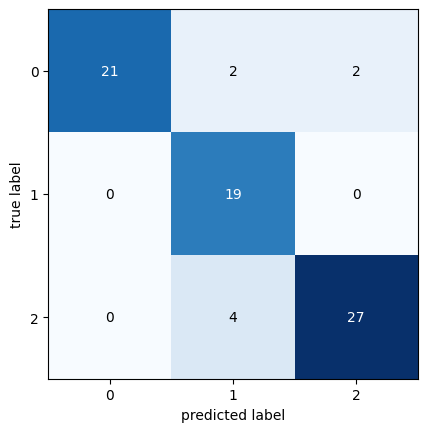

In [71]:
# TODO
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

conf_mat = ConfusionMatrix(task='multiclass', num_classes=3)
test_truth = torch.tensor(test_dataloader.dataset.targets)
pred_test = torch.tensor(pred_test)
confusion_matrix = conf_mat(pred_test, test_truth)
plot_confusion_matrix(confusion_matrix.numpy());

## 2. Get the "most wrong" of the predictions on the test dataset and plot the 5 "most wrong" images. You can do this by:
* Predicting across all of the test dataset, storing the labels and predicted probabilities.
* Sort the predictions by *wrong prediction* and then *descending predicted probabilities*, this will give you the wrong predictions with the *highest* prediction probabilities, in other words, the "most wrong".
* Plot the top 5 "most wrong" images, why do you think the model got these wrong?

You'll want to:
* Create a DataFrame with sample, label, prediction, pred prob
* Sort DataFrame by correct (does label == prediction)
* Sort DataFrame by pred prob (descending)
* Plot the top 5 "most wrong" image predictions

In [72]:
# TODO
import pandas as pd 
# to get the prediction probability
def get_prediction_probs(model,dataloader):
    model.eval()
    pred_prob_list = []
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logit_preds = model(X)
            pred_probs = torch.softmax(logit_preds, 1).max(axis=1).values.cpu().numpy()
            pred_prob_list.extend(pred_probs)
    
    return pred_prob_list

samples = np.arange(len(test_dataloader.dataset.targets))
label = test_dataloader.dataset.targets 
prediction = pred_test.numpy()
pred_prob = get_prediction_probs(model_0, test_dataloader)
df_dict = {'samples': samples,
           'label': label,
           'prediction': prediction,
           'pred_prob': pred_prob}


In [73]:
df = pd.DataFrame(df_dict)
df['correct'] = df['prediction'] == df['label']
df.sort_values(by=['correct', 'pred_prob'], ascending=[True, False], inplace=True)

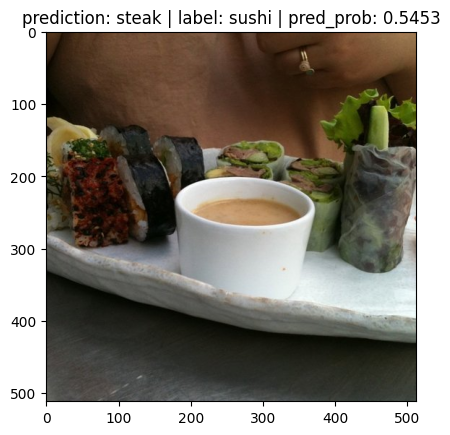

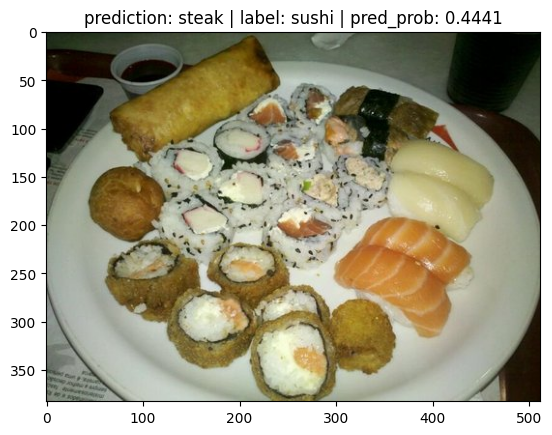

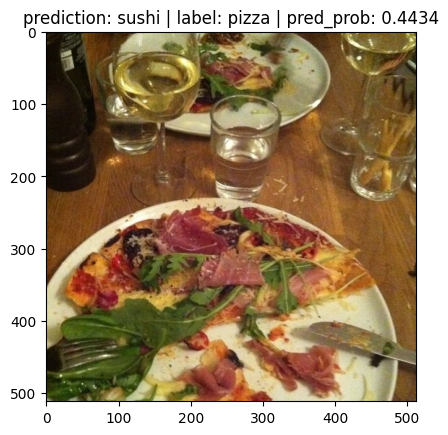

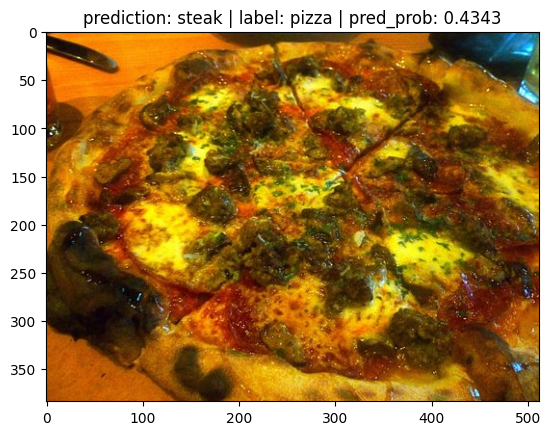

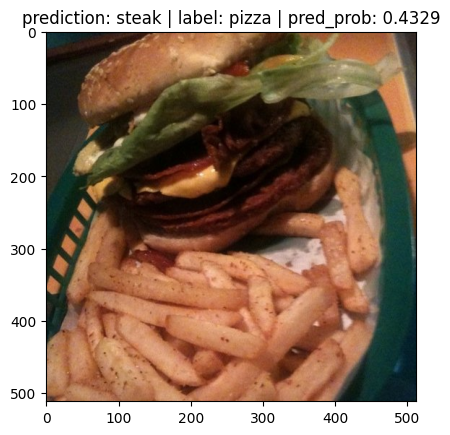

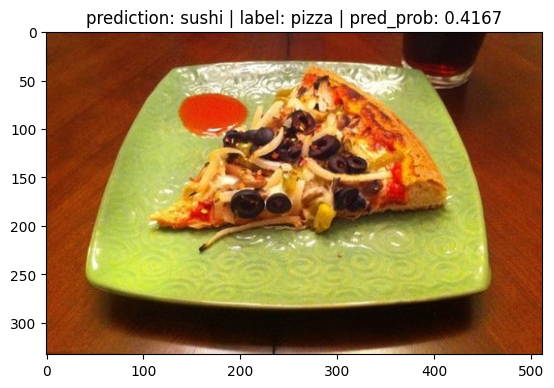

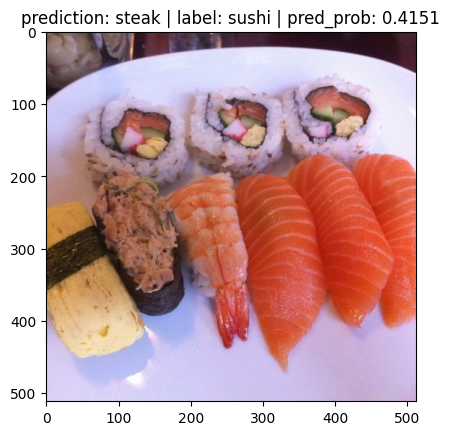

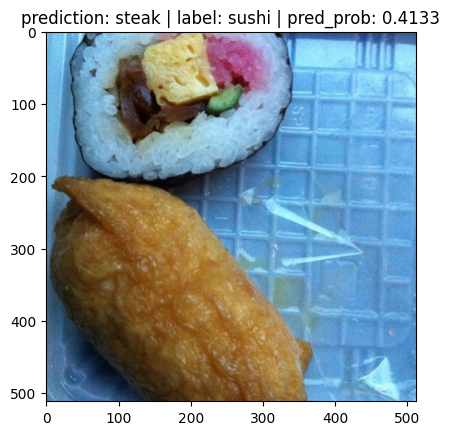

In [74]:
from PIL import Image
from matplotlib import pyplot as plt
most_wrong_samples = df.loc[:, 'samples'].values[:8]
test_images = list(test_dir.glob("*/*.jpg"))
for sample in most_wrong_samples:
    img = Image.open(test_images[sample])
    prediction_txt = test_dataloader.dataset.classes[df.loc[df.loc[:,'samples']==sample,'prediction'].values[0]]
    label_txt = test_dataloader.dataset.classes[df.loc[df.loc[:,'samples']==sample,'label'].values[0]]
    pred_prob = df.loc[df.loc[:,'samples']==sample,'pred_prob'].values[0]
    plt.imshow(img)
    plt.title(f"prediction: {prediction_txt} | label: {label_txt} | pred_prob: {pred_prob:.4f}")
    plt.show()

## 3. Predict on your own image of pizza/steak/sushi - how does the model go? What happens if you predict on an image that isn't pizza/steak/sushi?
* Here you can get an image from a website like http://www.unsplash.com to try it out or you can upload your own.

In [75]:
# TODO: Get an image of pizza/steak/susshi
from pathlib import Path
external_path = Path("./external_images/")


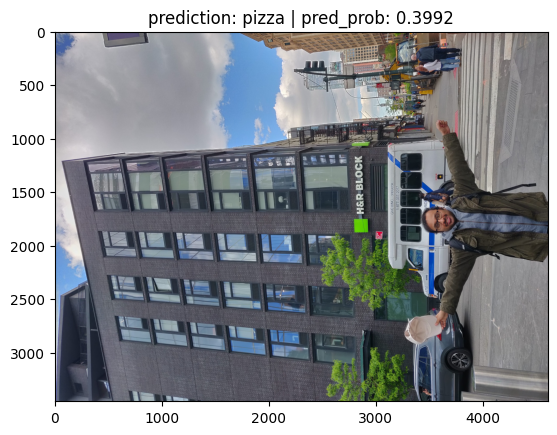

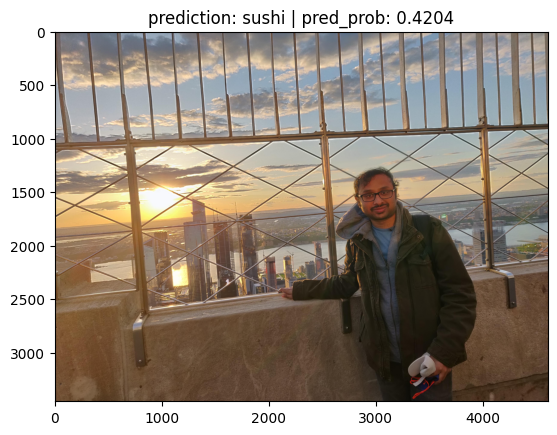

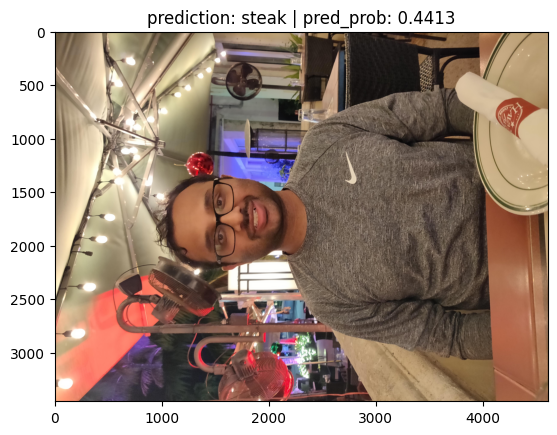

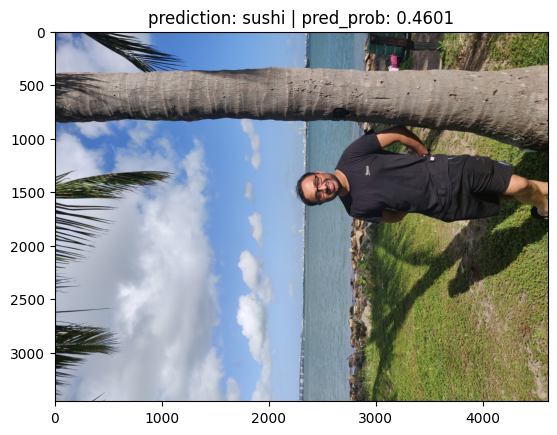

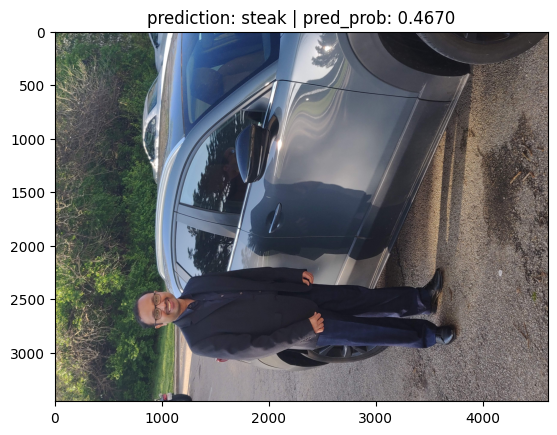

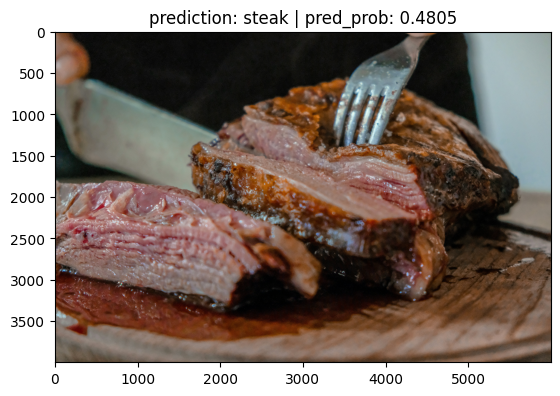

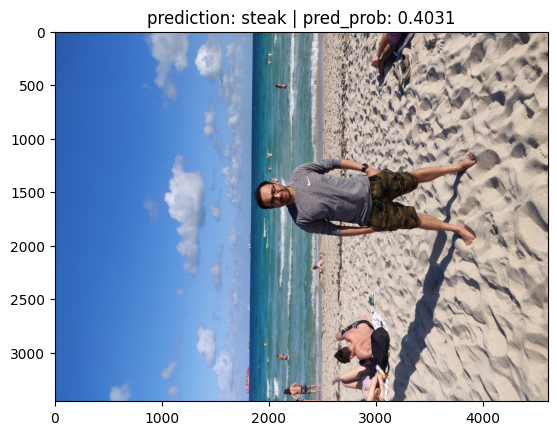

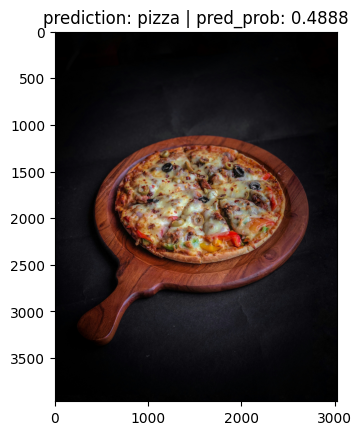

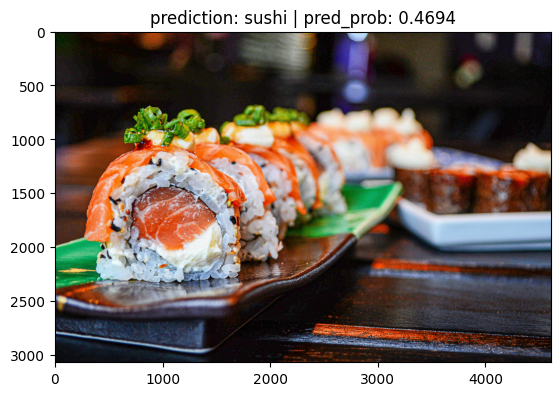

In [76]:
from PIL import Image
import matplotlib.pyplot as plt
external_iamge_paths = list(external_path.glob("*.jpg"))
for p in external_iamge_paths:
    img = Image.open(p)
    transformed_image = simple_transform(img)
    logit_preds = model_0(transformed_image.unsqueeze(0).to(device))
    prediction = test_dataloader.dataset.classes[logit_preds.softmax(dim=1).argmax(dim=1).item()]
    pred_prob = logit_preds.softmax(dim=1).max().item()
    plt.imshow(img)
    plt.title(f"prediction: {prediction} | pred_prob: {pred_prob:0.4f}")
    plt.show()

In [77]:
# TODO: Get an image of not pizza/steak/sushi


## 4. Train the model from section 4  in notebook 06 part 3 for longer (10 epochs should do), what happens to the performance?

* See the model in notebook 06 part 3 for reference: https://www.learnpytorch.io/06_pytorch_transfer_learning/#3-getting-a-pretrained-model

In [78]:
# TODO: Recreate a new model 
import torchvision

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [79]:
for p in model.features.parameters():
    p.requires_grad = False

In [80]:
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features=1280, out_features=3, bias=True)
)

## 5. Train the model from section 4 above with more data, say 20% of the images from Food101 of Pizza, Steak and Sushi images.
* You can find the [20% Pizza, Steak, Sushi dataset](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip) on the course GitHub. It was created with the notebook [`extras/04_custom_data_creation.ipynb`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb). 


### Get 20% data

In [81]:
import os
import requests
import zipfile

from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"
image_data_zip_path = "pizza_steak_sushi_20_percent.zip"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / image_data_zip_path, "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / image_data_zip_path, "r") as zip_ref:
        print("Unzipping pizza, steak, sushi 20% data...") 
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / image_data_zip_path)

# Setup Dirs
train_dir_20_percent = image_path / "train"
test_dir_20_percent = image_path / "test"

train_dir_20_percent, test_dir_20_percent

data\pizza_steak_sushi_20_percent directory exists.


(WindowsPath('data/pizza_steak_sushi_20_percent/train'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test'))

### Create DataLoaders

In [82]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [83]:
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader_20_percent, test_dataloader_20_percent, class_names = data_setup.create_dataloaders(train_dir=train_dir_20_percent,
                                                                                                     test_dir=test_dir_20_percent,
                                                                                                     transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                                                     batch_size=32) # set mini-batch size to 32

train_dataloader_20_percent, test_dataloader_20_percent, class_names

(<torch.utils.data.dataloader.DataLoader at 0x23337c57d10>,
 ['pizza', 'steak', 'sushi'])

### Get a pretrained model

In [84]:
# TODO
import torchvision

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

### Train a model with 20% of the data

In [85]:
# TODO
#fixing the learned parameters of hidden layers
for p in model.features.parameters():
    p.requires_grad = False

#modifying the output layer for my problem
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_features=1280, out_features=3, bias=True)
)

In [86]:
# Specifying the loss functions and optimizers
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [87]:
model_results = engine.train(model=model,
                             train_dataloader=train_dataloader_20_percent,
                             test_dataloader=test_dataloader_20_percent,
                             optimizer=optimizer,
                             loss_fn=loss_fn,
                             epochs=5,
                             device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9422 | train_acc: 0.6500 | test_loss: 0.6551 | test_acc: 0.8818
Epoch: 2 | train_loss: 0.6804 | train_acc: 0.8333 | test_loss: 0.5269 | test_acc: 0.9131
Epoch: 3 | train_loss: 0.5240 | train_acc: 0.8625 | test_loss: 0.4387 | test_acc: 0.9159
Epoch: 4 | train_loss: 0.4502 | train_acc: 0.8917 | test_loss: 0.4022 | test_acc: 0.9068
Epoch: 5 | train_loss: 0.4323 | train_acc: 0.8708 | test_loss: 0.3561 | test_acc: 0.9256


In [88]:
for k in dir(train_dataloader_20_percent):
    if not k.endswith("__") and not k.startswith("__"):
        print(k)

_DataLoader__initialized
_DataLoader__multiprocessing_context
_IterableDataset_len_called
_auto_collation
_dataset_kind
_get_iterator
_index_sampler
_is_protocol
_iterator
batch_sampler
batch_size
check_worker_number_rationality
collate_fn
dataset
drop_last
generator
multiprocessing_context
num_workers
persistent_workers
pin_memory
pin_memory_device
prefetch_factor
sampler
timeout
worker_init_fn


In [89]:
len(train_dataloader_20_percent.dataset.targets), len(test_dataloader_20_percent.dataset.targets)

(450, 150)

## 6. Try a different model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) on the Pizza, Steak, Sushi data, how does this model perform?
* You'll have to change the size of the classifier layer to suit our problem.
* You may want to try an EfficientNet with a higher number than our B0, perhaps `torchvision.models.efficientnet_b2()`?
  * **Note:** Depending on the model you use you will have to prepare/transform the data in a certain way.

In [90]:
from torchvision.models import EfficientNet_V2_M_Weights, efficientnet_v2_m
from IPython.display import display, Markdown

In [91]:
weights_v2 = EfficientNet_V2_M_Weights.DEFAULT
transforms_new = weights_v2.transforms()

In [92]:
# to combine the datasets
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import ConcatDataset

In [93]:
simple_transforms_v2 = transforms.Compose([
    transforms.Resize((480,480)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [94]:
#combining the two datasets
def combine_datasets(dir_1, dir_2):
    dataset_1 = ImageFolder(root=dir_1, transform=simple_transforms_v2)
    dataset_2 = ImageFolder(root=dir_2, transform=simple_transforms_v2)

    return ConcatDataset([dataset_1, dataset_2])

combined_train_dataset = combine_datasets(train_dir, train_dir_20_percent)
combined_test_dataset = combine_datasets(test_dir, test_dir_20_percent)


In [95]:
ImageFolder(root=train_dir, transform=simple_transforms_v2).find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [96]:
#creating the dataloaders
from torch.utils.data import DataLoader

train_dataloader_combined = DataLoader(dataset=combined_train_dataset, batch_size=32, shuffle=True)
test_dataloader_combined = DataLoader(dataset=combined_test_dataset, batch_size=32, shuffle=True)


In [97]:
model_combined = efficientnet_v2_m(weights=EfficientNet_V2_M_Weights.DEFAULT)

In [98]:
for p in model_combined.features.parameters():
    p.requires_grad = False

In [99]:
model_combined.classifier = nn.Sequential(
    nn.Dropout(0.3, inplace=True),
    nn.Linear(in_features=1280, out_features=3)
)

In [100]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_combined.parameters(), lr=0.01)

In [101]:
# TODO 
from timeit import default_timer as timer

start_time = timer()
results = engine.train(model=model_combined,
                       train_dataloader=train_dataloader_combined,
                       test_dataloader=test_dataloader_combined,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)
end_time = timer()
print(f"Total running time: {end_time-start_time:0.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9553 | train_acc: 0.6364 | test_loss: 0.7898 | test_acc: 0.8125
Epoch: 2 | train_loss: 0.7288 | train_acc: 0.8385 | test_loss: 0.5839 | test_acc: 0.9258
Epoch: 3 | train_loss: 0.6253 | train_acc: 0.8471 | test_loss: 0.5006 | test_acc: 0.9023
Epoch: 4 | train_loss: 0.5298 | train_acc: 0.9025 | test_loss: 0.4341 | test_acc: 0.9219
Epoch: 5 | train_loss: 0.4740 | train_acc: 0.9025 | test_loss: 0.4077 | test_acc: 0.9648
Total running time: 610.152 seconds
